# Intro
This Notebook is to aggretate the dataset that is extract feature from finbert and LLM. 

# News Data

## Data import

In [46]:
import pandas as pd

news_df = pd.read_csv('finbert_llm_sentiment_inserted.csv')

print(news_df.shape)
display(news_df.head())

(451165, 11)


/var/folders/s2/gqpw_6dd5n7b8c1hzy_q5s0w0000gn/T/ipykernel_21700/2466372152.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  news_df = pd.read_csv('finbert_llm_sentiment_inserted.csv')


,date,headline,sentiment_score_finbert,sentiment_positive_finbert,sentiment_neutral_finbert,sentiment_negative_finbert,sentiment_score,relevance_score,event_importance,event_type,sentiment_score_llm
0,2006-11-13 03:16:00-05:00,"Hitachi, GE boost alliance in nuclear power bu...",0.284925,0.826591,0.162399,0.011009,NaN,0.4,0.3,merger,0.2
1,2006-11-13 08:45:00-05:00,"Volvo to cut 1,000 staff at Virginia plant",-0.348377,0.007027,0.025183,0.967790,NaN,0.4,0.3,supply-chain,-0.6
2,2006-11-13 03:15:00-05:00,European banks hiding full pension obligations,0.003950,0.039472,0.938750,0.021779,NaN,0.6,0.5,regulatory,-0.4
3,2006-11-13 07:13:00-05:00,"Hitachi, GE to form joint nuclear power ventures",0.010726,0.059743,0.928143,0.012114,NaN,0.6,0.4,merger,0.2
4,2006-11-13 07:29:00-05:00,Eddie Bauer agrees to be bought for $286 million,0.035885,0.156745,0.834435,0.008820,NaN,0.4,0.3,merger,0.2


## Remove non model input features
For better performance in weak computer(small amount of ram)

In [47]:
news_df = news_df.drop(columns=['headline'])
display(news_df.head())

,date,sentiment_score_finbert,sentiment_positive_finbert,sentiment_neutral_finbert,sentiment_negative_finbert,sentiment_score,relevance_score,event_importance,event_type,sentiment_score_llm
0,2006-11-13 03:16:00-05:00,0.284925,0.826591,0.162399,0.011009,NaN,0.4,0.3,merger,0.2
1,2006-11-13 08:45:00-05:00,-0.348377,0.007027,0.025183,0.967790,NaN,0.4,0.3,supply-chain,-0.6
2,2006-11-13 03:15:00-05:00,0.003950,0.039472,0.938750,0.021779,NaN,0.6,0.5,regulatory,-0.4
3,2006-11-13 07:13:00-05:00,0.010726,0.059743,0.928143,0.012114,NaN,0.6,0.4,merger,0.2
4,2006-11-13 07:29:00-05:00,0.035885,0.156745,0.834435,0.008820,NaN,0.4,0.3,merger,0.2


## Sort by Date

In [48]:
# sort by date
news_df = news_df.sort_values('date')
display(news_df.head())

,date,sentiment_score_finbert,sentiment_positive_finbert,sentiment_neutral_finbert,sentiment_negative_finbert,sentiment_score,relevance_score,event_importance,event_type,sentiment_score_llm
59458,2006-10-20 20:16:16-04:00,0.312001,0.914320,0.022552,0.063128,NaN,NaN,NaN,NaN,NaN
30003,2006-10-21 00:08:44-04:00,0.000008,0.026059,0.947917,0.026024,NaN,0.6,0.3,analyst,0.2
269287,2006-10-23 11:51:36-04:00,0.051074,0.235344,0.723311,0.041345,NaN,NaN,NaN,NaN,NaN
269286,2006-10-23 20:00:29-04:00,-0.269634,0.041104,0.151949,0.806947,NaN,NaN,NaN,NaN,NaN
264729,2006-10-24 01:32:04-04:00,0.006762,0.046718,0.936810,0.016472,NaN,NaN,NaN,NaN,NaN


# Price data

## yFinance library

In [49]:
import yfinance as yf

def download_finance_data(
    symbol: str,
    start_date: str,
    end_date: str,
    interval: str = '1d'
) -> pd.DataFrame:
    """Download financial data from Yahoo Finance.
    
    Args:
        symbol (str): Stock symbol (e.g., '^SPX')
        start_date (str): Start date in 'YYYY-MM-DD' format
        end_date (str): End date in 'YYYY-MM-DD' format
        interval (str): Data interval ('1d' for daily, '1h' for hourly, etc.)
    
    Returns:
        pd.DataFrame: The downloaded data
    """
    # Download data from Yahoo Finance
    print(f"Downloading {interval} data for {symbol}...")
    ticker = yf.Ticker(symbol)
    df = ticker.history(start=start_date, end=end_date, interval=interval)
    
    # Reset index to make Date a column
    df = df.reset_index()
    
    # Print data information
    print(f"\nData shape: {df.shape}")
    print("Columns in the dataset:")
    print(df.columns.tolist())
    
    return df

## Download the price data by the date range of the news data

In [50]:
# Convert date column to datetime first
news_df['date'] = pd.to_datetime(news_df['date'])

# Get the min and max dates from news_df (day only)
start_date = news_df['date'].min().strftime('%Y-%m-%d')
end_date = news_df['date'].max().strftime('%Y-%m-%d')

print(f"Date range: {start_date} to {end_date}")

Date range: 2006-10-20 to 2013-11-26


/var/folders/s2/gqpw_6dd5n7b8c1hzy_q5s0w0000gn/T/ipykernel_21700/1276877657.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  news_df['date'] = pd.to_datetime(news_df['date'])


In [51]:
# Download S&P 500 data for the date range
spx_df = None
try:
    spx_df = download_finance_data(
        symbol='^SPX',
        start_date=start_date,
        end_date=end_date,
        interval='1d'
    )
    # Display first few rows
    print("\nFirst few rows of S&P 500 data:")
    print(spx_df.head())
except Exception as e:
    print(f"Error downloading data: {e}")
    pass


Error downloading data: Too Many Requests. Rate limited. Try after a while.


Note: When working with yFinance API, you may encounter common issues such as rate limiting or discontinued symbols. 
These are typical challenges when working with financial data APIs. If you experience these issues:
1. First try updating to the latest version of yFinance using: pip install --upgrade yfinance
2. If problems persist, you can manually download the data from Yahoo Finance and import it using the code below

In [52]:
if spx_df is None:
    spx_df = pd.read_csv('SPX_1d.csv')
spx_df.head()

,Date,Open,High,Low,Close,Volume
0,2006-10-20 00:00:00-04:00,1366.939941,1368.660034,1362.099976,1368.599976,2526410000
1,2006-10-23 00:00:00-04:00,1368.579956,1377.400024,1363.939941,1377.020020,2480430000
2,2006-10-24 00:00:00-04:00,1377.020020,1377.780029,1372.420044,1377.380005,2876890000
3,2006-10-25 00:00:00-04:00,1377.359985,1383.609985,1376.000000,1382.219971,2953540000
4,2006-10-26 00:00:00-04:00,1382.209961,1389.449951,1379.469971,1389.079956,2793350000


## Insert Technical Indicators

In [53]:
import pandas as pd
import numpy as np
from ta import add_all_ta_features
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator, MFIIndicator
from ta.trend import CCIIndicator
from typing import List, Dict

def calculate_technical_indicators(df: pd.DataFrame, indicators: List[Dict]) -> pd.DataFrame:
    """
    Calculate technical indicators for the given price data using ta library.
    
    Args:
        df (pd.DataFrame): Price data with OHLCV columns
        indicators (List[Dict]): List of indicator configurations
            Each dict should have:
            - name: str, name of the indicator
            - window: int (optional), window size for the indicator
            
    Returns:
        pd.DataFrame: DataFrame with calculated indicators
        
    Example:
        indicators = [
            {'name': 'bb', 'window': 20},
            {'name': 'rsi', 'window': 14}
        ]
        df_with_indicators = calculate_technical_indicators(price_df, indicators)
    """
    if df is None:
        raise ValueError("DataFrame is not initialized")
    
    for indicator in indicators:
        name = indicator['name']
        window = indicator.get('window', None)
        
        try:
            if name == 'bb':
                bb = BollingerBands(close=df['close'], window=window)
                df[f'bb_upper_{window}'] = bb.bollinger_hband()
                df[f'bb_middle_{window}'] = bb.bollinger_mavg()
                df[f'bb_lower_{window}'] = bb.bollinger_lband()
                
            elif name == 'ma':
                ma = SMAIndicator(close=df['close'], window=window)
                df[f'ma_{window}'] = ma.sma_indicator()
                
            elif name == 'ema':
                ema = EMAIndicator(close=df['close'], window=window)
                df[f'ema_{window}'] = ema.ema_indicator()
                
            elif name == 'rsi':
                rsi = RSIIndicator(close=df['close'], window=window)
                df[f'rsi_{window}'] = rsi.rsi()
                
            elif name == 'macd':
                macd = MACD(close=df['close'], window_slow=window, window_fast=12, window_sign=9)
                df[f'macd_{window}'] = macd.macd()
                df[f'macd_signal_{window}'] = macd.macd_signal()
                df[f'macd_hist_{window}'] = macd.macd_diff()
                
            elif name == 'atr':
                atr = AverageTrueRange(high=df['high'], low=df['low'], close=df['close'], window=window)
                df[f'atr_{window}'] = atr.average_true_range()
                
            elif name == 'cci':
                cci = CCIIndicator(high=df['high'], low=df['low'], close=df['close'], window=window)
                df[f'cci_{window}'] = cci.cci()
                
            elif name == 'stochastic':
                stoch = StochasticOscillator(high=df['high'], low=df['low'], close=df['close'], window=window)
                df[f'stoch_k_{window}'] = stoch.stoch()
                df[f'stoch_d_{window}'] = stoch.stoch_signal()
                
            elif name == 'obv':
                obv = OnBalanceVolumeIndicator(close=df['close'], volume=df['volume'])
                df['obv'] = obv.on_balance_volume()
                
            elif name == 'mfi':
                mfi = MFIIndicator(high=df['high'], low=df['low'], close=df['close'], volume=df['volume'], window=window)
                df[f'mfi_{window}'] = mfi.money_flow_index()
        except Exception as e:
            raise Exception(f"Error calculating {name} indicator: {str(e)}")
    
    return df

In [54]:
# Convert the column name to lower case
spx_df.columns = spx_df.columns.str.lower()

# INDICATORS = [
#         {'name': 'bb', 'window': 20},
#         {'name': 'ma', 'window': 20},
#         {'name': 'ema', 'window': 20},
#         {'name': 'rsi', 'window': 14},
#         {'name': 'macd', 'window': 26},  # MACD slow window
#         {'name': 'atr', 'window': 14},
#         {'name': 'cci', 'window': 20},
#         {'name': 'stochastic', 'window': 14},
#         {'name': 'obv'},
#         {'name': 'mfi', 'window': 14}
#     ]
INDICATORS = [
    {'name': 'bb', 'window': 20},          # Bollinger Bands
    {'name': 'ma', 'window': 50},          # Simple Moving Average
    {'name': 'ema', 'window': 12},         # Exponential Moving Average
    {'name': 'rsi', 'window': 14},         # Relative Strength Index
    {'name': 'macd', 'window': 26},        # MACD slow window (fast=12, signal=9)
    {'name': 'atr', 'window': 14},         # Average True Range
    {'name': 'cci', 'window': 20},         # Commodity Channel Index
    {'name': 'stochastic', 'window': 14},  # Stochastic oscillator (%K)
    {'name': 'adx', 'window': 14},         # Average Directional Index
    {'name': 'vortex', 'window': 14},      # Vortex Indicator
    {'name': 'obv'},                       # On-Balance Volume
    {'name': 'mfi', 'window': 14},         # Money Flow Index
    {'name': 'vwap'}                       # Volume-Weighted Average Price
]

spx_df = calculate_technical_indicators(spx_df, INDICATORS)



## Trading Day
We are aggreate the news by trading day instead of day, so will need to get the list of trading from the price data.

In [55]:
# Get unique trading dates from SPX data
trading_dates = spx_df['date'].unique().tolist()
print(f"Number of trading days: {len(trading_dates)}")
print("\nFirst few trading dates:")
print(trading_dates[:5])


Number of trading days: 1787

First few trading dates:
['2006-10-20 00:00:00-04:00', '2006-10-23 00:00:00-04:00', '2006-10-24 00:00:00-04:00', '2006-10-25 00:00:00-04:00', '2006-10-26 00:00:00-04:00']


In [56]:
# Sort news dataframe by date
news_df = news_df.sort_values('date')

# No need to convert timezone since it's already in US/Eastern
# Just ensure it's datetime
news_df['date'] = pd.to_datetime(news_df['date'], utc=True)

# Aggreate Data

## Assign Trading Day


In [57]:
def assign_trading_days(news_df, price_df):
    """
    Assign trading days to news articles and convert price dates to trading days.
    For price data: Convert dates to trading days with 4 PM ET time
    For news data: Assign trading days based on timestamp rules (before/after 4 PM)
    
    Args:
        news_df (pd.DataFrame): News data with 'date' column
        price_df (pd.DataFrame): Price data with 'date' column
        
    Returns:
        None: Modifies both DataFrames in place
    """
    # Ensure dates are in datetime format with UTC
    news_df['date'] = pd.to_datetime(news_df['date'], utc=True)
    price_df['date'] = pd.to_datetime(price_df['date'], utc=True)
    
    # Convert price dates to trading days with 4 PM ET
    price_df['trading_day'] = price_df['date'].apply(
        lambda x: pd.Timestamp(
            year=x.year,
            month=x.month,
            day=x.day,
            hour=16,
            minute=0,
            second=0,
            tz='US/Eastern'
        )
    )
    
    # Get unique trading dates from price data and convert to list for sorting
    trading_dates = sorted(price_df['trading_day'].unique().tolist())
    
    # Create a mapping of dates to next trading day
    date_to_next_trading = {}
    for i in range(len(trading_dates) - 1):
        current_trading = trading_dates[i]
        next_trading = trading_dates[i + 1]
        date_to_next_trading[current_trading.date()] = current_trading
        
        # Fill in all dates between current and next trading day
        current = current_trading.date()
        while current < next_trading.date():
            current = (pd.Timestamp(current) + pd.Timedelta(days=1)).date()
            date_to_next_trading[current] = next_trading
    
    # Function to determine trading day for a news article
    def get_trading_day(news_date):
        # Convert to US/Eastern timezone
        news_date = news_date.tz_convert('US/Eastern')
        news_time = news_date.time()
        news_date = news_date.date()
        
        # If news is after 4 PM, assign to next trading day
        if news_time >= pd.Timestamp('16:00').time():
            # Find the next trading day
            for trading_day in trading_dates:
                if trading_day.date() > news_date:
                    return trading_day
            return None
        else:
            # If news is before 4 PM, assign to current trading day
            return date_to_next_trading.get(news_date)
    
    # Apply the function to assign trading days to news data
    news_df['trading_day'] = news_df['date'].apply(get_trading_day)

## Calculate weighted sentiment

In [58]:
import numpy as np

def insert_weighted_sentiment_llm(
    news_df: pd.DataFrame,
    price_df: pd.DataFrame,
    trading_dates: list[pd.Timestamp],
    half_life_days: float
):
    """
    Calculate and insert weighted sentiment score from LLM, considering relevance,
    event importance, and time decay.

    Args:
        news_df: DataFrame with columns
            ['date', 'relevance_score', 'event_importance', 'event_type', 'sentiment_score_llm']
        price_df: DataFrame with ['date'] column
        trading_dates: List of trading date values (dates or datetime)
        half_life_days: Half-life for exponential decay (in days)

    Returns:
        None: Modifies news_df in place by adding 'weighted_sentiment_llm' column
    """
    # Ensure dates are in datetime format
    news_df['date'] = pd.to_datetime(news_df['date'], utc=True)
    price_df['date'] = pd.to_datetime(price_df['date'], utc=True)
    
    # Assign trading days using the new function
    assign_trading_days(news_df, price_df)
    
    # Drop rows where trading_day is None
    news_df = news_df.dropna(subset=['trading_day'])

    # Compute decay factor
    lam = np.log(2) / half_life_days
    delta = (news_df['trading_day'] - news_df['date']).dt.total_seconds() / (24*3600)
    delta = np.clip(delta, 0, None)
    news_df['decay'] = np.exp(-lam * delta)

    # Calculate weighted sentiment score
    news_df['weighted_sentiment_llm'] = (
        news_df['sentiment_score_llm'] * 
        news_df['relevance_score'] * 
        news_df['event_importance'] * 
        news_df['decay']
    )

## Aggreate Function

In [59]:
def aggregate_news_price_data(
    news_df: pd.DataFrame,
    price_df: pd.DataFrame,
    event_types: list[str],
    half_life_days: float = 1.5
):
    """
    Calculate weighted sentiment and aggregate news and price data by trading day.

    Args:
        news_df: DataFrame with columns
            ['date', 'relevance_score', 'event_importance', 'event_type', 'sentiment_score_llm']
        price_df: DataFrame with ['date', 'close', 'volume']
        event_types: List of all possible event types
        half_life_days: Half-life for exponential decay (in days)

    Returns:
        pd.DataFrame: Aggregated data with one-hot encoded event types and price data
    """
    # Ensure dates are in datetime format
    news_df['date'] = pd.to_datetime(news_df['date'], utc=True)
    price_df['date'] = pd.to_datetime(price_df['date'], utc=True)
    
    # Assign trading days
    assign_trading_days(news_df, price_df)
    
    # Drop rows where trading_day is None
    news_df = news_df.dropna(subset=['trading_day']).copy()

    # Compute decay factor
    lam = np.log(2) / half_life_days
    delta = (news_df['trading_day'] - news_df['date']).dt.total_seconds() / (24*3600)
    delta = np.clip(delta, 0, None)
    news_df['decay'] = np.exp(-lam * delta)

    # Calculate weighted sentiment score
    news_df['weighted_sentiment_llm'] = (
        news_df['sentiment_score_llm'] * 
        news_df['relevance_score'] * 
        news_df['event_importance'] * 
        news_df['decay']
    )

    # One-hot encode event_type
    news_df['event_type'] = pd.Categorical(news_df['event_type'], categories=event_types)
    dummies = pd.get_dummies(news_df['event_type']).reindex(columns=event_types, fill_value=0)
    
    # Multiply one-hot encoded columns by weighted sentiment
    weighted_dummies = dummies.mul(news_df['weighted_sentiment_llm'], axis=0)
    
    # Add trading_day to the weighted dummies (preserve the full datetime with timezone)
    weighted_dummies['trading_day'] = news_df['trading_day']
    
    # Aggregate news data by trading day
    news_agg = (
        weighted_dummies
        .groupby('trading_day')
        .sum()
        .reset_index()
    )
    
    # Prepare price data - convert dates to 4 PM ET trading days
    price_df['trading_day'] = price_df['date'].apply(
        lambda x: pd.Timestamp(
            year=x.year,
            month=x.month,
            day=x.day,
            hour=16,
            minute=0,
            second=0,
            tz='US/Eastern'
        )
    )
    price_df.drop(columns=['date'])
    
    # Merge news and price data
    merged_df = pd.merge(
        price_df,
        news_agg,
        on='trading_day',
        how='left'
    ).fillna(0.0)
    
    # Sort by trading day
    merged_df = merged_df.sort_values('trading_day').reset_index(drop=True)
    
    return merged_df

## Aggreate!

In [60]:
# Define event types
EVENT_TYPES = [
    "earnings", "merger", "dividend", "guidance", "regulatory",
    "macroeconomic", "monetary", "CEO change", "product launch",
    "supply-chain", "credit", "scandal", "analyst", "sector-wide",
    "geopolitical", "other"
]

# Aggregate the data
aggregated_df = aggregate_news_price_data(
    news_df=news_df,
    price_df=spx_df,
    event_types=EVENT_TYPES,
    half_life_days=1.5
)

In [61]:
# Display results
print("\nFirst few rows of aggregated data:")
display(aggregated_df.head())
print(aggregated_df.shape)


First few rows of aggregated data:


,date,open,high,low,close,volume,bb_upper_20,bb_middle_20,bb_lower_20,ma_50,...,monetary,CEO change,product launch,supply-chain,credit,scandal,analyst,sector-wide,geopolitical,other
0,2006-10-20 04:00:00+00:00,1366.939941,1368.660034,1362.099976,1368.599976,2526410000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,2006-10-23 04:00:00+00:00,1368.579956,1377.400024,1363.939941,1377.020020,2480430000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.010528,0.0,0.0,0.0
2,2006-10-24 04:00:00+00:00,1377.020020,1377.780029,1372.420044,1377.380005,2876890000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,2006-10-25 04:00:00+00:00,1377.359985,1383.609985,1376.000000,1382.219971,2953540000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,2006-10-26 04:00:00+00:00,1382.209961,1389.449951,1379.469971,1389.079956,2793350000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


(1787, 38)


# Save csv

In [62]:
aggregated_df.to_csv('aggregated_data.csv', index=False)

# Model Training

## Training Pipeline

In [63]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import optuna
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from typing import Callable, Dict, Any, Tuple
from sklearn.metrics import mean_squared_error, f1_score

def print_performance_metrics(actual, predictions):
    """
    Print MSE, directional accuracy, and F1 score for regression predictions.
    
    Args:
        actual (np.ndarray): Actual values (1D array)
        predictions (np.ndarray): Predicted values (1D array)
    """
    # 1. MSE
    mse = mean_squared_error(actual, predictions)
    print(f"MSE: {mse:.4f}")

    # 2. Directional Accuracy
    actual_direction = np.sign(np.diff(actual))
    pred_direction = np.sign(np.diff(predictions))
    directional_accuracy = np.mean(actual_direction == pred_direction)
    print(f"Directional Accuracy: {directional_accuracy:.4f}")

    # 3. F1 Score for Direction
    actual_binary = (actual_direction > 0).astype(int)
    pred_binary = (pred_direction > 0).astype(int)
    f1 = f1_score(actual_binary, pred_binary)
    print(f"F1 Score (direction): {f1:.4f}")

def create_sequences(data, seq_length, target_col_idx):
    """Create sequences for time series data."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, target_col_idx])
    return np.array(X), np.array(y)

def prepare_data_for_model(df: pd.DataFrame, seq_length: int, test_size: float = 0.2) -> Tuple:
    """Prepare data for the model, handling datetime columns properly."""
    # Create a copy of the dataframe
    df = df.copy()
    
    # Store the datetime column separately
    datetime_col = df['trading_day']
    
    # Get numeric columns (excluding datetime)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df_numeric = df[numeric_cols]
    
    # Scale the numeric data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df_numeric)
    
    # Find the index of the 'close' column
    close_col_idx = list(numeric_cols).index('close')
    
    # Create sequences
    X, y = create_sequences(scaled_data, seq_length, close_col_idx)
    
    # Split into train and test sets
    train_size = int(len(X) * (1 - test_size))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Get corresponding dates for test set
    test_dates = datetime_col[train_size + seq_length:].values
    
    return X_train, X_test, y_train, y_test, scaler, test_dates, numeric_cols

### LSTM + CNN

In [64]:
def build_cnn_lstm_model(trial: optuna.Trial, seq_length: int, n_features: int) -> tf.keras.Model:
    """Default CNN+LSTM model architecture."""
    # CNN parameters
    cnn_filters = trial.suggest_int('cnn_filters', 32, 128)
    cnn_kernel = trial.suggest_int('cnn_kernel', 2, 5)
    cnn_dropout = trial.suggest_float('cnn_dropout', 0.1, 0.5)
    
    # LSTM parameters
    lstm_units = trial.suggest_int('lstm_units', 32, 128)
    lstm_dropout = trial.suggest_float('lstm_dropout', 0.1, 0.5)
    
    # Learning rate
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    
    model = Sequential([
        # Input layer
        Input(shape=(seq_length, n_features)),

        # CNN layers
        Conv1D(filters=cnn_filters, kernel_size=cnn_kernel, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(cnn_dropout),
        
        # LSTM layers
        LSTM(lstm_units, return_sequences=True),
        Dropout(lstm_dropout),
        LSTM(lstm_units // 2),
        Dropout(lstm_dropout),
        
        # Output layer
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

### LSTM

In [65]:
def build_lstm_model(trial: optuna.Trial, seq_length: int, n_features: int, **kwargs) -> tf.keras.Model:
    """Custom model architecture example."""
    # Example of a different architecture
    lstm_units = trial.suggest_int('lstm_units', 32, 128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    
    model = Sequential([
        Input(shape=(seq_length, n_features)),
        LSTM(lstm_units, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units // 2),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

### Train and Evaluate

In [66]:
def train_and_evaluate_model(
    news_df: pd.DataFrame,
    price_df: pd.DataFrame,
    event_types: list,
    seq_length: int,
    n_trials: int = 20,
    build_model_fn: Callable = build_cnn_lstm_model,
    model_params: Dict[str, Any] = None,
    half_life_range: tuple = (0.5, 10.0)
) -> Tuple:
    """
    Train and evaluate the model with hyperparameter optimization, including half_life_days as a hyperparameter.

    Args:
        news_df: Raw news DataFrame
        price_df: Raw price DataFrame
        event_types: List of event types for one-hot encoding
        seq_length: Length of input sequences
        n_trials: Number of Optuna trials
        build_model_fn: Model building function
        model_params: Additional model parameters
        half_life_range: (min, max) range for half_life_days

    Returns:
        Tuple containing (model, history, predictions, actual, test_dates, best_params)
    """
    import optuna

    def objective(trial):
        # 1. Suggest half_life_days for this trial
        half_life_days = trial.suggest_float('half_life_days', half_life_range[0], half_life_range[1])

        # 2. Aggregate data using the suggested half_life_days
        aggregated_df = aggregate_news_price_data(
            news_df, price_df, event_types, half_life_days=half_life_days
        )

        # 3. Prepare data for the model
        X_train, X_test, y_train, y_test, scaler, test_dates, numeric_cols = prepare_data_for_model(
            aggregated_df, seq_length=seq_length
        )

        # 4. Split training data into train and validation sets
        val_size = int(len(X_train) * 0.2)
        X_train_final, X_val = X_train[:-val_size], X_train[-val_size:]
        y_train_final, y_val = y_train[:-val_size], y_train[-val_size:]

        # 5. Build and train the model
        model = build_model_fn(trial, seq_length, X_train.shape[2], **(model_params or {}))
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
        history = model.fit(
            X_train_final, y_train_final,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )

        # 6. Return the best validation loss
        return min(history.history['val_loss'])

    # 7. Run Optuna optimization
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    # 8. After finding the best trial, rebuild the dataset with the best half_life_days
    best_half_life = study.best_params['half_life_days']
    best_aggregated_df = aggregate_news_price_data(
        news_df, price_df, event_types, half_life_days=best_half_life
    )

    # 9. Prepare data for the final model
    X_train, X_test, y_train, y_test, scaler, test_dates, numeric_cols = prepare_data_for_model(
        best_aggregated_df, seq_length=seq_length
    )

    # 10. Train the final model with the best hyperparameters
    best_model = build_model_fn(study.best_trial, seq_length, X_train.shape[2], **(model_params or {}))
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    history = best_model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1
    )

    # 11. Make predictions
    predictions = best_model.predict(X_test)
    close_col_idx = list(numeric_cols).index('close')
    pred_reshaped = np.zeros((len(predictions), len(numeric_cols)))
    pred_reshaped[:, close_col_idx] = predictions.flatten()
    predictions = scaler.inverse_transform(pred_reshaped)[:, close_col_idx]
    actual_reshaped = np.zeros((len(y_test), len(numeric_cols)))
    actual_reshaped[:, close_col_idx] = y_test
    actual = scaler.inverse_transform(actual_reshaped)[:, close_col_idx]

    # 11. Print the best hyperparameters found
    print("Best hyperparameters found:")
    for k, v in study.best_params.items():
        print(f"{k}: {v}")

    # Print performance metrics
    print_performance_metrics(actual, predictions)

    return best_model, history, predictions, actual, test_dates, study.best_params

### Plot Results

In [67]:
def plot_results(predictions, actual, test_dates, history):
    """Plot the results and training history."""
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot predictions vs actual
    ax1.plot(test_dates, actual, label='Actual', color='blue')
    ax1.plot(test_dates, predictions, label='Predicted', color='red')
    ax1.set_title('Actual vs Predicted Stock Prices')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Plot training history
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss During Training')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

## Test LSTM + CNN

[I 2025-05-26 00:16:10,878] A new study created in memory with name: no-name-b2c48e30-b5fb-408d-985f-4d59d7f7267c
[I 2025-05-26 00:17:07,533] Trial 0 finished with value: 0.0013027962995693088 and parameters: {'half_life_days': 2.4912485937038893, 'cnn_filters': 92, 'cnn_kernel': 2, 'cnn_dropout': 0.4233861980434405, 'lstm_units': 71, 'lstm_dropout': 0.2867138823931582, 'learning_rate': 7.133114747459536e-05}. Best is trial 0 with value: 0.0013027962995693088.
[I 2025-05-26 00:18:03,273] Trial 1 finished with value: 0.0008446176652796566 and parameters: {'half_life_days': 2.9568383154911935, 'cnn_filters': 122, 'cnn_kernel': 3, 'cnn_dropout': 0.29670583611221096, 'lstm_units': 77, 'lstm_dropout': 0.2990531595909829, 'learning_rate': 0.002784908237335594}. Best is trial 1 with value: 0.0008446176652796566.
[I 2025-05-26 00:18:59,654] Trial 2 finished with value: 0.0010424591600894928 and parameters: {'half_life_days': 6.580523951283317, 'cnn_filters': 82, 'cnn_kernel': 5, 'cnn_dropout':

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0733 - val_loss: 0.0014
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0089 - val_loss: 0.0012
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0054 - val_loss: 0.0012
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - val_loss: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - val_loss: 9.1710e-04
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - val_loss: 9.6933e-04
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - val_loss: 8.6379e-04
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

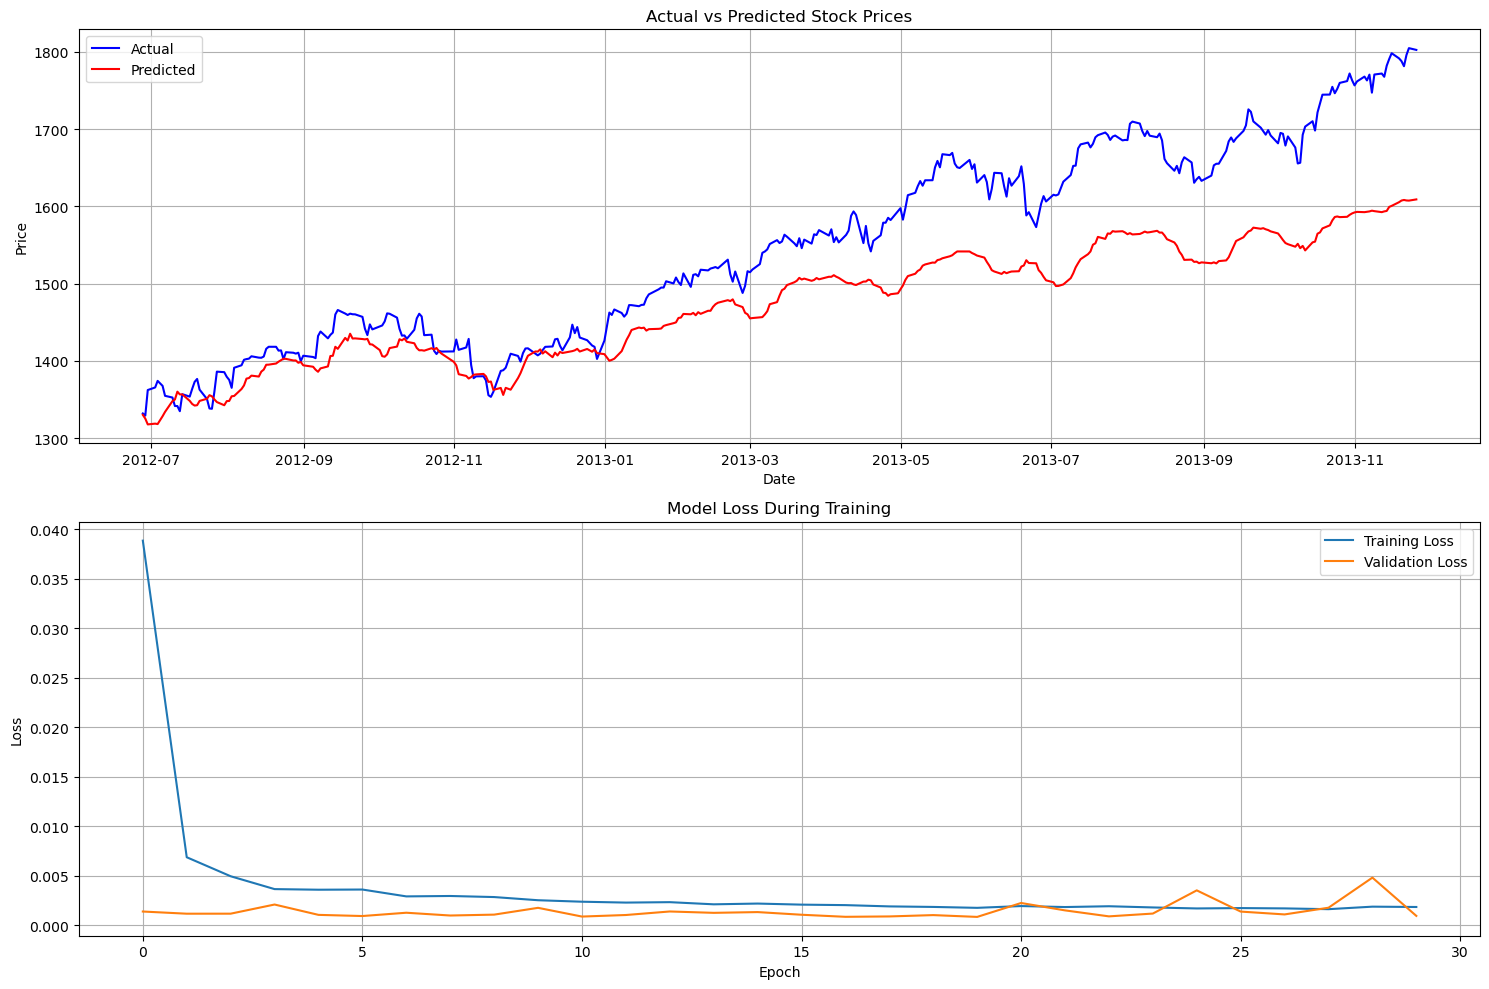

In [68]:
seq_length = 10
n_trials = 20

# 3. Call the function
best_model, history, predictions, actual, test_dates, best_params = train_and_evaluate_model(
    news_df=news_df,
    price_df=spx_df,
    event_types=EVENT_TYPES,
    seq_length=seq_length,
    n_trials=n_trials,
    build_model_fn=build_cnn_lstm_model,  # or your custom model function
    model_params=None,                    # or pass a dict of extra model params if needed
    half_life_range=(0.5, 10.0)           # or any range you want to search
)

# 5. (Optional) Plot results
plot_results(predictions, actual, test_dates, history)

# Save the model to a file (e.g., HDF5 format)
best_model.save('LSTM_CNN_Model.h5')

## Test LSTM

[I 2025-05-26 00:36:52,852] A new study created in memory with name: no-name-4b2359aa-5a15-40bf-ab43-9cc166d248a7
[I 2025-05-26 00:37:52,250] Trial 0 finished with value: 0.0029286888893693686 and parameters: {'half_life_days': 9.405787430210406, 'lstm_units': 38, 'dropout_rate': 0.45807362339398205, 'learning_rate': 0.0004497889720210848}. Best is trial 0 with value: 0.0029286888893693686.
[I 2025-05-26 00:38:51,904] Trial 1 finished with value: 0.001151939621195197 and parameters: {'half_life_days': 3.9133493468279656, 'lstm_units': 119, 'dropout_rate': 0.2710381373121533, 'learning_rate': 0.00019738618595932037}. Best is trial 1 with value: 0.001151939621195197.
[I 2025-05-26 00:39:54,542] Trial 2 finished with value: 0.0013081844663247466 and parameters: {'half_life_days': 4.275735597285965, 'lstm_units': 68, 'dropout_rate': 0.3813026519224898, 'learning_rate': 0.0007256020361928025}. Best is trial 1 with value: 0.001151939621195197.
[I 2025-05-26 00:40:46,811] Trial 3 finished wit

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2836 - val_loss: 0.0056
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0466 - val_loss: 0.0047
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0337 - val_loss: 0.0019
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0254 - val_loss: 0.0012
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0168 - val_loss: 0.0015
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0115 - val_loss: 0.0017
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 - val_loss: 0.0015
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0087 - val_loss: 0.0014
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 - val_loss: 0.0013
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0075 - val_loss: 0.0014
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0069 - val_loss: 0.0013
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.

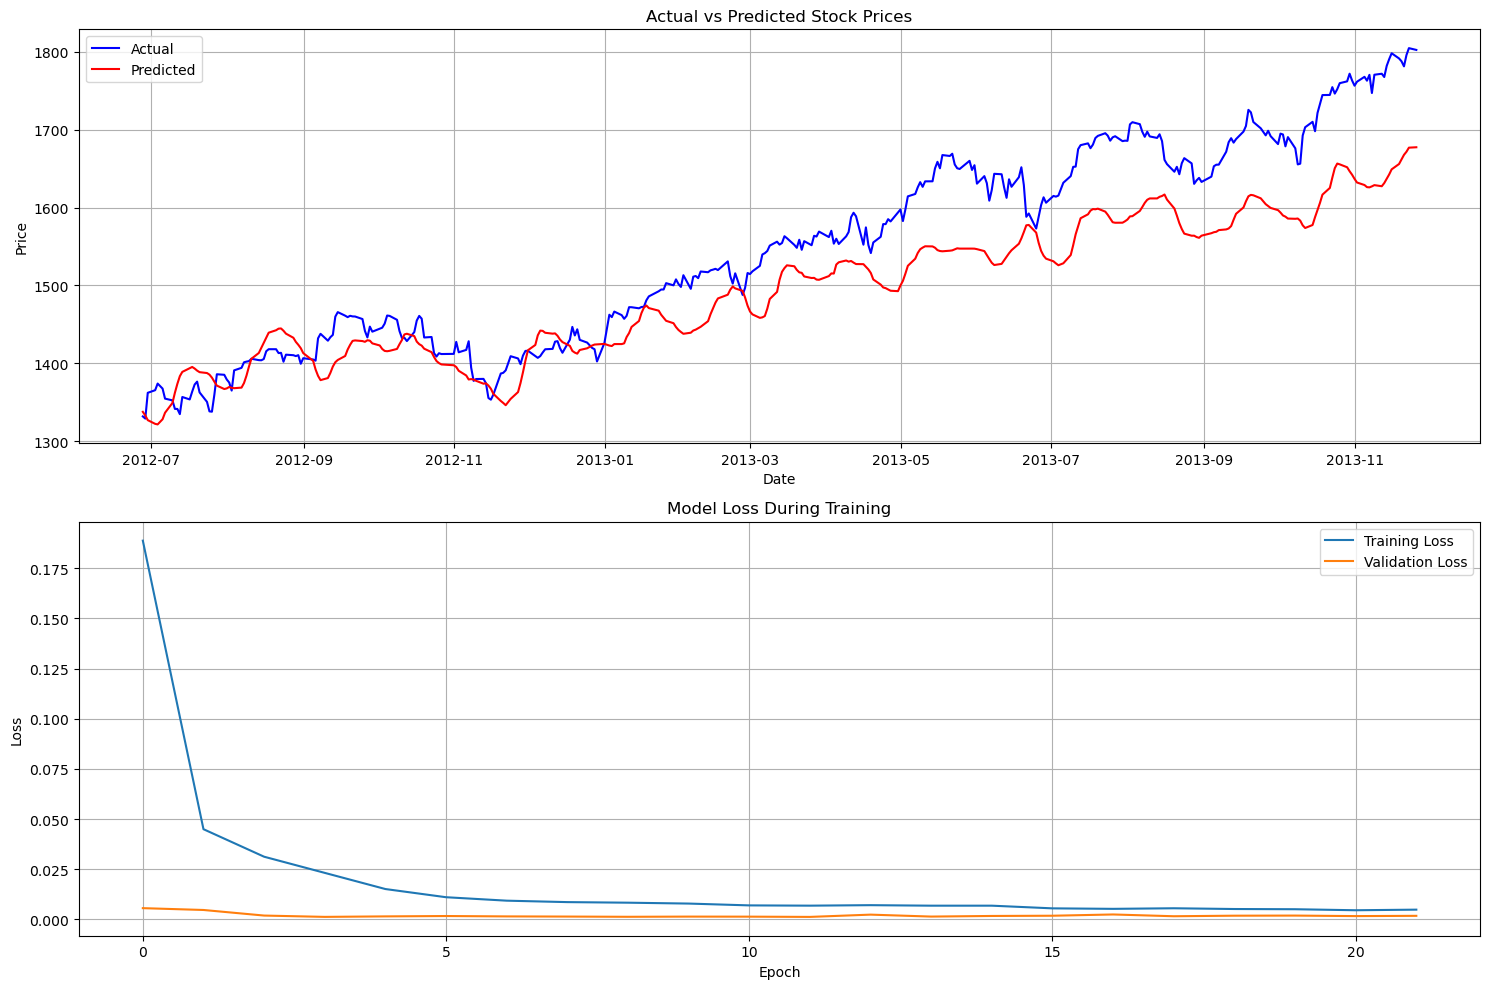

In [69]:
seq_length = 10
n_trials = 20

# 3. Call the function
best_model, history, predictions, actual, test_dates, best_params = train_and_evaluate_model(
    news_df=news_df,
    price_df=spx_df,
    event_types=EVENT_TYPES,
    seq_length=seq_length,
    n_trials=n_trials,
    build_model_fn=build_lstm_model,  # or your custom model function
    model_params=None,                    # or pass a dict of extra model params if needed
    half_life_range=(0.5, 10.0)           # or any range you want to search
)

# 5. (Optional) Plot results
plot_results(predictions, actual, test_dates, history)

# Save the model to a file (e.g., HDF5 format)
best_model.save('LSTM_Model.h5')